# Fig 4: decoding and representation

Linear: **SHI-59**. Paper title: *insula functional clusters encode speech-specific representations*.

**Articulator (PhonemeSequence Repeat).** Windowed accuracy (Stimulus / Delay / Response), confusion, and electrode maps. First-phoneme labels (`recording-1`). Clusters are bilateral hard-label pools. STG / SMC / MFG are left-hemisphere anatomical controls.

**Lexicality (LexicalDelay).** Time-resolved shrinkage-LDA AUC (Repeat / Decision × Stimulus / Delay / Response). STG is the left-hemisphere positive control.

**Cross-condition (LexicalDelay Delay).** 2D Repeat ↔ Decision temporal generalization with the same shrinkage-LDA path. Four-panel heatmap is Repeat→Decision for Sensory / Sustain / Motor / STG. A second overlay stacks the three insula clusters (AUC only inside significant contours).

Style: [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md). SVG only.


In [3]:
%matplotlib inline

import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter1d

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.connectivity.pairwise.config import DEFAULT_DATASETS
from src.nmf.waveform_analysis import FUNCTION_COLORS
from src.paths import img_dir, nmf_assignments_path, resolve_decoding_task_root, save_svg

In [4]:
from matplotlib import font_manager

for _ttf in (Path(sys.prefix) / "fonts").glob("arial*.ttf"):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

fontsize = 7
fontdict = dict(fontsize=fontsize)

REF = "bipolar"
BAND = "highgamma"
DATATYPE = "articulator"
DESCRIPTION = "Repeat"
PHASES = ["Stimulus", "Delay", "Response"]
TASK = "PhonemeSequence"
N_CLASSES = 4
CHANCE = 1.0 / N_CLASSES
SIG_P = 0.05

HUE_ORDER = ["Sensory", "Sustain", "Motor", "STG", "SMC", "MFG"]
FUNCTIONAL_ROIS = {"Sensory", "Sustain", "Motor"}
ANATOMICAL_ROIS = {"STG", "SMC", "MFG", "IFG"}

ROI_COLOR_MAP = {
    "Sensory": FUNCTION_COLORS["sensory"],
    "Sustain": FUNCTION_COLORS["sustain"],
    "Motor": FUNCTION_COLORS["motor"],
    "STG": "#20B2AA",
    "SMC": "#6A5ACD",
    "MFG": "#666666",
    "IFG": "#C45C26",
}

FUNCTIONAL_ROOT = ROOT / "results" / "decoding"
ANATOMICAL_ROOT = Path("/hpc/group/coganlab/nanlinshi/insula/results")
RESULTS_ROOTS = [FUNCTIONAL_ROOT, ANATOMICAL_ROOT]
PREPARED_ROOT = Path(DEFAULT_DATASETS[TASK]) / "derivatives" / f"decoding({REF})"
CLUSTERS = ["sensory", "sustain", "motor"]
IMG_DIR = img_dir("fig4")

## Load windowed articulator scores

Reads `(decode)articulator` fold accuracies. PhonemeSequence files carry
`recording-1` (first phoneme); LexicalDelay files have no recording entity,
so that filter is not applied there.


In [5]:
rows = []
seen = set()
for root_base in RESULTS_ROOTS:
    task_root = resolve_decoding_task_root(root_base, TASK, ref=REF)
    if task_root is None:
        continue
    for h5_path in task_root.glob(f"sub-*/(decode){DATATYPE}/*_{BAND}.h5"):
        key = str(h5_path.resolve())
        if key in seen:
            continue
        seen.add(key)

        parts = {}
        for token in h5_path.stem.split("_"):
            if "-" not in token:
                continue
            entity, value = token.split("-", 1)
            parts[entity] = value

        subject = parts["sub"]
        if subject in FUNCTIONAL_ROIS:
            roi, hemi = subject, "LR"
        elif subject.endswith("l"):
            roi, hemi = subject[:-1], "Left"
        elif subject.endswith("r"):
            roi, hemi = subject[:-1], "Right"
        else:
            roi, hemi = subject, "LR"

        if roi not in HUE_ORDER:
            continue
        if parts.get("desc") != DESCRIPTION:
            continue
        if roi in ANATOMICAL_ROIS and hemi != "Left":
            continue
        if roi in FUNCTIONAL_ROIS and hemi != "LR":
            continue
        if parts.get("recording") != "1":
            continue

        with h5py.File(h5_path, "r") as mat:
            accuracy = np.asarray(mat["accuracy"][()], dtype=float)
            accuracy_stable = float(mat["accuracy_stable"][()])
            p_value = float(mat["p_value"][()])
            n_classes = len(np.asarray(mat["classes"][()]))

        for fold_i, acc in enumerate(accuracy):
            rows.append(
                {
                    "fold": fold_i,
                    "accuracy": acc,
                    "accuracy_stable": accuracy_stable,
                    "p_value": p_value,
                    "n_classes": n_classes,
                    "roi": roi,
                    "phase": parts["proc"],
                    "hemi": hemi,
                    "h5_path": str(h5_path),
                }
            )

scores = pd.DataFrame(rows)
print("TASK", TASK, "n_files", scores.groupby(["roi", "phase"])["h5_path"].nunique().unstack(fill_value=0))
print(scores.drop_duplicates(["roi", "phase"])[["roi", "phase", "accuracy_stable", "p_value"]].sort_values(["phase", "roi"]).to_string(index=False))

TASK PhonemeSequence n_files phase    Delay  Go  Response  Stimulus
roi                                   
MFG          1   1         1         1
Motor        1   1         1         1
SMC          1   1         1         1
STG          1   1         1         1
Sensory      1   1         1         1
Sustain      1   1         1         1
    roi    phase  accuracy_stable  p_value
    MFG    Delay         0.396722 0.004975
  Motor    Delay         0.266472 0.398010
    SMC    Delay         0.395194 0.004975
    STG    Delay         0.568944 0.004975
Sensory    Delay         0.248306 0.457711
Sustain    Delay         0.317917 0.009950
    MFG       Go         0.357611 0.024876
  Motor       Go         0.354500 0.044776
    SMC       Go         0.428278 0.004975
    STG       Go         0.439861 0.004975
Sensory       Go         0.175972 0.572139
Sustain       Go         0.288528 0.935323
    MFG Response         0.451306 0.004975
  Motor Response         0.313306 0.014925
    SMC Respon

## Articulator window accuracy

Bars are fold means ± SE; `*` is permutation `p < 0.05`.
Dashed line is chance (1 / 4 classes).


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_articulator_PhonemeSequence.svg


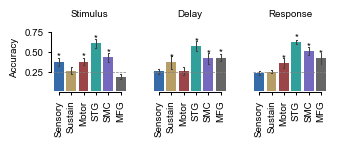

In [6]:
present = [roi for roi in HUE_ORDER if roi in set(scores["roi"])]
vals = scores["accuracy"].dropna()
ymin = max(0.0, float(vals.min()) - 0.08)
ymax = max(float(vals.max()) + 0.08, CHANCE + 0.08)

fig, axes = plt.subplots(1, len(PHASES), figsize=(3.0 * len(PHASES) * cm, 3.0 * cm))
fig.subplots_adjust(wspace=0.35, bottom=0.32)

for j, phase in enumerate(PHASES):
    ax = axes[j]
    subset = scores[scores["phase"] == phase]
    phase_rois = [roi for roi in present if roi in set(subset["roi"])]
    palette = [ROI_COLOR_MAP[roi] for roi in phase_rois]

    if phase_rois:
        sns.barplot(
            data=subset,
            x="roi",
            y="accuracy",
            hue="roi",
            order=phase_rois,
            hue_order=phase_rois,
            palette=palette,
            legend=False,
            ax=ax,
            errorbar="se",
            capsize=0.08,
            err_kws={"linewidth": 0.75},
            linewidth=0,
        )
        sig = (
            subset.groupby("roi", as_index=True)["p_value"]
            .first()
            .loc[lambda s: s < SIG_P]
        )
        patches = [p for p in ax.patches if p.get_height() > 0 or p.get_width() > 0]
        if len(patches) < len(phase_rois):
            patches = list(ax.patches)[: len(phase_rois)]
        for i, roi in enumerate(phase_rois):
            if roi not in sig.index or i >= len(patches):
                continue
            patch = patches[i]
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height() + patch.get_y() + 0.01
            ax.text(
                x,
                min(y, ymax - 0.01),
                "*",
                ha="center",
                va="bottom",
                fontsize=fontsize,
            )

    ax.axhline(y=CHANCE, color="gray", linestyle="--", lw=0.5)
    ax.set_ylim(ymin, ymax)
    ax.set_title(phase, fontsize=fontsize)
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy" if j == 0 else "", fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if j != 0:
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize)
    if phase_rois:
        ax.set_xticks(range(len(phase_rois)))
        ax.set_xticklabels(
            phase_rois, rotation=90, ha="center", va="top", fontsize=fontsize
        )

out = save_svg(fig, IMG_DIR / "fig4_articulator_PhonemeSequence")
print("Wrote", out)

## Articulator confusion (phase-matched clusters)

Row-normalized out-of-fold confusion for the three significant
cluster × phase cells: Sensory–Stimulus, Sustain–Delay, Motor–Response.
Each heatmap uses `sns.light_palette` of that cluster's `FUNCTION_COLORS`.
Color scale is anchored at chance (0.25); below-chance cells stay near white.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_articulator_PhonemeSequence_confusion.svg


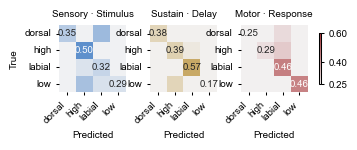

In [7]:
CLASS_LABELS = ["dorsal", "high", "labial", "low"]
CONFUSION_PANELS = [
    ("Sensory", "Stimulus"),
    ("Sustain", "Delay"),
    ("Motor", "Response"),
]
vmin = CHANCE
vmax = 0.60

fig, axes = plt.subplots(
    1, len(CONFUSION_PANELS), figsize=(3.0 * len(CONFUSION_PANELS) * cm, 3 * cm)
)
fig.subplots_adjust(wspace=0.35, bottom=0.28, right=0.88)

for j, (roi, phase) in enumerate(CONFUSION_PANELS):
    ax = axes[j]
    hit = scores[(scores["roi"] == roi) & (scores["phase"] == phase)]
    if hit.empty:
        ax.set_axis_off()
        ax.set_title(f"{roi} · {phase}", fontsize=fontsize)
        continue

    h5_path = Path(hit["h5_path"].iloc[0])
    with h5py.File(h5_path, "r") as mat:
        conf = np.asarray(mat["confusion_norm"][()], dtype=float)

    annot = np.empty(conf.shape, dtype=object)
    annot[:] = ""
    np.fill_diagonal(annot, [f"{v:.2f}" for v in np.diag(conf)])
    cmap = sns.light_palette(ROI_COLOR_MAP[roi], as_cmap=True)
    sns.heatmap(
        conf,
        annot=annot,
        fmt="",
        cmap=cmap,
        annot_kws={"size": fontsize},
        cbar=False,
        vmin=vmin,
        vmax=vmax,
        square=True,
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
        ax=ax,
    )
    ax.set_title(f"{roi} · {phase}", fontsize=fontsize)
    ax.set_xlabel("Predicted", fontsize=fontsize)
    ax.set_ylabel("True" if j == 0 else "", fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

cbar = fig.colorbar(
    axes[-1].collections[0],
    ax=axes,
    fraction=0.03,
    pad=0.04,
    shrink=0.72,
)
cbar.ax.tick_params(labelsize=fontsize, width=0.75, length=2)
cbar.set_ticks([CHANCE, 0.40, 0.60])
plt.setp(cbar.ax.spines.values(), linewidth=0.75)

out = save_svg(fig, IMG_DIR / "fig4_articulator_PhonemeSequence_confusion")
print("Wrote", out)

In [8]:
assignments = pd.read_csv(nmf_assignments_path())
channel_rows = []
for roi in ["Sensory", "Sustain", "Motor"]:
    cluster = roi.lower()
    for phase in PHASES:
        h5_path = (
            PREPARED_ROOT
            / f"sub-{roi}"
            / DATATYPE
            / (
                f"sub-{roi}_task-{TASK}_proc-{phase}_recording-1"
                f"_desc-{DESCRIPTION}_{BAND}.h5"
            )
        )
        if not h5_path.exists():
            print("missing", h5_path)
            continue
        with h5py.File(h5_path, "r") as mat:
            chans = [
                c.decode() if isinstance(c, bytes) else str(c) for c in mat["channel"][:]
            ]
        for ch in chans:
            channel_rows.append(
                {
                    "channel": ch,
                    "prepared_cluster": cluster,
                    "phase": phase,
                    "roi": roi,
                }
            )

pool = pd.DataFrame(channel_rows)
print(
    "n channels by phase × cluster\n",
    pool.groupby(["phase", "prepared_cluster"])["channel"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=PHASES, columns=CLUSTERS),
)

united = (
    pool.drop_duplicates(subset=["channel"], keep="first")
    .merge(
        assignments[["channel", "x", "y", "z", "hemi", "functional_cluster"]],
        on="channel",
        how="left",
    )
)
mismatch = united.loc[
    united["functional_cluster"].notna()
    & (united["functional_cluster"] != united["prepared_cluster"])
]
print("union channels", united["channel"].nunique())
print("missing xyz", int(united[["x", "y", "z"]].isna().any(axis=1).sum()))
print("cluster mismatch", len(mismatch))
if len(mismatch):
    print(mismatch[["channel", "prepared_cluster", "functional_cluster"]].to_string(index=False))
print(
    united.groupby("functional_cluster")["channel"]
    .nunique()
    .reindex(CLUSTERS)
    .fillna(0)
    .astype(int)
    .to_string()
)

anatomical_rows = []
for roi in ["STG", "SMC", "MFG"]:
    subject = f"{roi}l"
    for phase in PHASES:
        h5_path = (
            PREPARED_ROOT
            / f"sub-{subject}"
            / DATATYPE
            / (
                f"sub-{subject}_task-{TASK}_proc-{phase}_recording-1"
                f"_desc-{DESCRIPTION}_{BAND}.h5"
            )
        )
        if not h5_path.exists():
            print("missing", h5_path)
            continue
        with h5py.File(h5_path, "r") as mat:
            chans = [
                c.decode() if isinstance(c, bytes) else str(c) for c in mat["channel"][:]
            ]
        for ch in chans:
            anatomical_rows.append({"channel": ch, "roi": roi, "phase": phase})

anatomical_pool = pd.DataFrame(anatomical_rows)
print(
    "n anatomical channels by phase × roi\n",
    anatomical_pool.groupby(["phase", "roi"])["channel"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=PHASES, columns=["STG", "SMC", "MFG"]),
)

parc_root = Path(DEFAULT_DATASETS[TASK]) / "derivatives" / "parcellation"
parc_frames = []
for csv in sorted(parc_root.glob("sub-*/bipolar/sub-*_hammers.csv")):
    parc = pd.read_csv(csv)
    parc_frames.append(
        pd.DataFrame(
            {
                "channel": parc["name"],
                "x": parc["x_t"],
                "y": parc["y_t"],
                "z": parc["z_t"],
                "hemi": parc["hemi"],
            }
        )
    )
parc_xyz = pd.concat(parc_frames, ignore_index=True).drop_duplicates("channel")

anatomical = (
    anatomical_pool.drop_duplicates(subset=["channel"], keep="first")
    .merge(parc_xyz, on="channel", how="left")
)
print("anatomical union", anatomical["channel"].nunique())
print("anatomical missing xyz", int(anatomical[["x", "y", "z"]].isna().any(axis=1).sum()))
print(
    anatomical.groupby("roi")["channel"]
    .nunique()
    .reindex(["STG", "SMC", "MFG"])
    .fillna(0)
    .astype(int)
    .to_string()
)


n channels by phase × cluster
 prepared_cluster  sensory  sustain  motor
phase                                    
Stimulus                9        9      8
Delay                   7       16     14
Response                2        8     54
union channels 83
missing xyz 0
cluster mismatch 4
     channel prepared_cluster functional_cluster
D0084_RAI4-5            motor            sustain
D0057_RAI3-4            motor            sustain
D0057_RAI4-5            motor            sustain
D0057_RAI5-6            motor            sustain
functional_cluster
sensory     9
sustain    21
motor      53
n anatomical channels by phase × roi
 roi       STG  SMC  MFG
phase                  
Stimulus  195  206  210
Delay     195  206  210
Response  195  206  210
anatomical union 611
anatomical missing xyz 0
roi
STG    195
SMC    206
MFG    210


Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot
plotting articulator Repeat channels: 83 | L 44 R 39


2026-09-11 10:40:00.430 (  32.696s) [    7F7C03D8C740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: pci id for fd 83: 10de:1e07, driver (null)

pci id for fd 84: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 83: 10de:1e07, driver (null)

pci id for fd 84: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-09-11 10:40:00.800 (  33.066s) [    7F7C03D8C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x7bba980): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 83: 10de:1e07, driver (null)

pci id for fd 84: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 83: 10de:1e07, driver (null)

pci id for fd 84: 10de:1e07, driv

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_articulator_PhonemeSequence_electrodes.svg
functional_cluster
sensory     9
sustain    21
motor      53


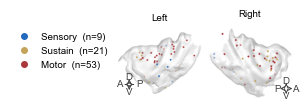

In [9]:
import os
import warnings

import mne
import pyvista as pv
from matplotlib.lines import Line2D
from mne.viz import Brain
from scipy.spatial import cKDTree

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")

recon_dir = "/cwork/ns458/ECoG_Recon/"
template = "cvs_avg35_inMNI152"
insula_patterns = (
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
)
POINT_SIZE = 13.0
CROP_PAD_PX = 24
INSULA_COLOR = (0.9, 0.9, 0.9)
INSULA_LABEL_ALPHA = 0.55

labels = mne.read_labels_from_annot(
    subject=template,
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
lh_pial_coords, lh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/lh.pial")
rh_pial_coords, rh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_vertices(hemi: str) -> np.ndarray:
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            verts.extend(lab.vertices)
    if not verts:
        raise RuntimeError(f"No insula labels for {hemi}")
    return np.unique(verts)


def _faces_to_polydata(coords, faces) -> pv.PolyData:
    faces_pv = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), np.asarray(faces, dtype=np.int64)]
    ).ravel()
    return pv.PolyData(np.asarray(coords, dtype=float), faces_pv)


def insula_mesh(hemi: str, pial: np.ndarray, faces: np.ndarray):
    verts = _insula_vertices(hemi)
    keep = np.all(np.isin(faces, verts), axis=1)
    mesh = _faces_to_polydata(pial, faces[keep])
    center = pial[verts].mean(axis=0)
    return mesh, center


lh_insula, lh_insula_center = insula_mesh("lh", lh_pial_coords, lh_faces)
rh_insula, rh_insula_center = insula_mesh("rh", rh_pial_coords, rh_faces)


def snap_to_pial(coords, tree, pial):
    _, idx = tree.query(coords)
    return pial[idx]


def add_cluster_spheres(brain, coords, clusters, tree, pial):
    coords = np.asarray(coords, dtype=float)
    if coords.size == 0:
        return np.zeros((0, 3), dtype=float)
    snapped = snap_to_pial(coords, tree, pial)
    for cluster in CLUSTERS:
        mask = np.asarray(clusters) == cluster
        if not mask.any():
            continue
        cloud = pv.PolyData(np.asarray(snapped[mask], dtype=float))
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=POINT_SIZE,
            color=FUNCTION_COLORS[cluster],
            lighting=False,
        )
    return snapped


def project_xy(plotter, points, image_shape):
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.zeros((0, 2), dtype=float)
    if hasattr(plotter, "project_points_to_pixels"):
        pix = np.asarray(plotter.project_points_to_pixels(pts), dtype=float)
        xy = np.asarray(pix[:, :2], dtype=float)
    else:
        import vtk

        renderer = plotter.renderer
        coordinate = vtk.vtkCoordinate()
        coordinate.SetCoordinateSystemToWorld()
        xy = np.zeros((len(pts), 2), dtype=float)
        for i, (x, y, z) in enumerate(pts):
            coordinate.SetValue(float(x), float(y), float(z))
            d = coordinate.GetComputedDisplayValue(renderer)
            xy[i] = (float(d[0]), float(d[1]))
    h = int(image_shape[0])
    xy[:, 1] = (h - 1) - xy[:, 1]
    return xy


def draw_ap_dv(ax, *, anterior_is_left: bool, corner: str):
    if corner == "lower left":
        x0, y0, arm = 0.16, 0.18, 0.08
    else:
        x0, y0, arm = 0.91, 0.16, 0.07
    gap = 0.012
    if anterior_is_left:
        tips = {"A": (x0 - arm, y0), "P": (x0 + arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    else:
        tips = {"A": (x0 + arm, y0), "P": (x0 - arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    for label, (tx, ty) in tips.items():
        sx = x0 + gap * np.sign(tx - x0) if tx != x0 else x0
        sy = y0 + gap * np.sign(ty - y0) if ty != y0 else y0
        ax.annotate(
            "",
            xy=(tx, ty),
            xytext=(sx, sy),
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="0.25", lw=0.7, mutation_scale=7),
            annotation_clip=False,
        )
        px = 0.03 * np.sign(tx - x0) if tx != x0 else 0.0
        py = 0.035 * np.sign(ty - y0) if ty != y0 else 0.0
        ax.text(
            tx + px,
            ty + py,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=fontsize,
            color="0.25",
            clip_on=False,
        )


def crop_to_content(img, xy, pad=CROP_PAD_PX):
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=2)
    if not mask.any():
        return rgb, np.asarray(xy, dtype=float)
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    xy_c = np.asarray(xy, dtype=float).copy()
    if xy_c.size:
        xy_c[:, 0] -= x0
        xy_c[:, 1] -= y0
    return rgb[y0:y1, x0:x1], xy_c


def render_hemi(hemi: str, coords, clusters):
    brain = Brain(
        template,
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=INSULA_COLOR,
        alpha=0.0,
        size=(800, 800),
    )
    plotter = brain._renderer.plotter
    mesh = lh_insula if hemi == "lh" else rh_insula
    plotter.add_mesh(
        mesh,
        color=INSULA_COLOR,
        opacity=INSULA_LABEL_ALPHA,
        lighting=True,
        smooth_shading=True,
    )
    tree = lh_tree if hemi == "lh" else rh_tree
    pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
    snapped = add_cluster_spheres(brain, coords, clusters, tree, pial)
    center = lh_insula_center if hemi == "lh" else rh_insula_center
    az = 180 if hemi == "lh" else 0
    brain.show_view(azimuth=az, elevation=90, distance=180, focalpoint=center)
    for _ in range(3):
        plotter.render()
    img = np.asarray(brain.screenshot(mode="rgb"))
    xy = project_xy(plotter, snapped, img.shape[:2])
    brain.close()
    return img, xy


spatial = united.loc[
    united["functional_cluster"].isin(CLUSTERS)
    & united[["x", "y", "z"]].notna().all(axis=1)
].copy()
cord = spatial[["x", "y", "z"]].to_numpy(float)
clust = spatial["functional_cluster"].to_numpy()
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0
print(
    "plotting articulator Repeat channels:",
    spatial.channel.nunique() if len(spatial) else 0,
    "| L",
    int(mask_lh.sum()),
    "R",
    int(mask_rh.sum()),
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lh_img, lh_xy = render_hemi("lh", cord[mask_lh], clust[mask_lh])
    rh_img, rh_xy = render_hemi("rh", cord[mask_rh], clust[mask_rh])

lh_img, lh_xy = crop_to_content(lh_img, lh_xy)
rh_img, rh_xy = crop_to_content(rh_img, rh_xy)

fig, axes = plt.subplots(1, 2, figsize=(6.5 * cm, 3.0 * cm))
for ax, img, title in (
    (axes[0], lh_img, "Left"),
    (axes[1], rh_img, "Right"),
):
    ax.imshow(img)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize)
    if title == "Left":
        draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
    else:
        draw_ap_dv(ax, anterior_is_left=False, corner="lower right")

n_by_cluster = spatial.groupby("functional_cluster")["channel"].nunique()
axes[0].legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=FUNCTION_COLORS[c],
            markeredgecolor=FUNCTION_COLORS[c],
            markersize=4,
            label=f"{c.capitalize()}  (n={int(n_by_cluster.get(c, 0))})",
        )
        for c in CLUSTERS
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
    bbox_to_anchor=(-0.04, 1.0),
    borderaxespad=0.0,
)
fig.subplots_adjust(wspace=0.02, left=0.28, right=0.98, top=0.92, bottom=0.02)
out = save_svg(fig, IMG_DIR / "fig4_articulator_PhonemeSequence_electrodes")
print("Wrote", out)
print(n_by_cluster.reindex(CLUSTERS).to_string())


## Anatomical control electrodes

Left-hemisphere STG / SMC / MFG channels that entered the same windowed
articulator decoder (Stimulus ∪ Delay ∪ Response, Repeat), drawn together on
one lateral pial at their original SEEG coordinates (not snapped to the
surface). Template midpoints from Hammers parcellation (`x_t`, `y_t`, `z_t`).


plotting anatomical Repeat channels: 611 | L 611 R 0


libEGL warning: pci id for fd 84: 10de:1e07, driver (null)

pci id for fd 85: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 84: 10de:1e07, driver (null)

pci id for fd 85: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-09-11 10:40:20.054 (  52.320s) [    7F7C03D8C740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xc5ea1a0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 84: 10de:1e07, driver (null)

pci id for fd 85: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 84: 10de:1e07, driver (null)

pci id for fd 85: 10de:1e07, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/ca

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_articulator_PhonemeSequence_electrodes_anatomical.svg
roi
STG    195
SMC    206
MFG    210


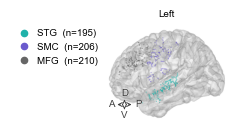

In [10]:
spatial_anat = anatomical.loc[anatomical[["x", "y", "z"]].notna().all(axis=1)].copy()
cord_anat = spatial_anat[["x", "y", "z"]].to_numpy(float)
roi_anat = spatial_anat["roi"].to_numpy()
mask_lh_anat = cord_anat[:, 0] < 0
print(
    "plotting anatomical Repeat channels:",
    spatial_anat.channel.nunique() if len(spatial_anat) else 0,
    "| L",
    int(mask_lh_anat.sum()),
    "R",
    int((cord_anat[:, 0] > 0).sum()),
)


def render_left_pial():
    brain = Brain(
        template,
        subjects_dir=recon_dir,
        surf="pial",
        hemi="lh",
        background="white",
        show=False,
        cortex=(0.82, 0.82, 0.82),
        alpha=0.35,
        size=(800, 800),
    )
    plotter = brain._renderer.plotter
    coords = np.asarray(cord_anat[mask_lh_anat], dtype=float)
    rois = roi_anat[mask_lh_anat]
    for roi in ["STG", "SMC", "MFG"]:
        mask = rois == roi
        if not mask.any():
            continue
        cloud = pv.PolyData(np.asarray(coords[mask], dtype=float))
        plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=6.0,
            color=ROI_COLOR_MAP[roi],
            lighting=False,
        )
    brain.show_view(view="lateral", distance=400)
    for _ in range(3):
        plotter.render()
    img = np.asarray(brain.screenshot(mode="rgb"))
    brain.close()
    return img


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lh_img_anat = render_left_pial()

lh_img_anat, _ = crop_to_content(lh_img_anat, np.zeros((0, 2)))
n_anat = spatial_anat[mask_lh_anat].groupby("roi")["channel"].nunique()

fig, ax = plt.subplots(figsize=(4.5 * cm, 4.0 * cm))
ax.imshow(lh_img_anat)
ax.set_xlim(0, lh_img_anat.shape[1])
ax.set_ylim(lh_img_anat.shape[0], 0)
ax.axis("off")
ax.set_title("Left", fontsize=fontsize)
draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=ROI_COLOR_MAP[roi],
            markeredgecolor=ROI_COLOR_MAP[roi],
            markersize=4.5,
            label=f"{roi}  (n={int(n_anat.get(roi, 0))})",
        )
        for roi in ["STG", "SMC", "MFG"]
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
    bbox_to_anchor=(-0.02, 1.0),
    borderaxespad=0.0,
    handletextpad=0.4,
)
fig.subplots_adjust(left=0.28, right=0.98, top=0.92, bottom=0.02)
out = save_svg(fig, IMG_DIR / "fig4_articulator_PhonemeSequence_electrodes_anatomical")
print("Wrote", out)
print(n_anat.reindex(["STG", "SMC", "MFG"]).to_string())


## Lexicality time-resolved (shrinkage-LDA)

Pooled out-of-fold AUC from `(decode)(resolved)(lda)lexicality`.
One SVG per condition (Repeat, Decision); columns are Stimulus / Delay / Response.
Chance is 0.5. Traces are ROI-colored; bars above the traces are
cluster-corrected significant windows. STG is the left-hemisphere positive control.


description    phase     roi  peak_auc  n_sig
     Repeat Stimulus Sensory  0.649312      0
   Decision Stimulus Sensory  0.584892      0
     Repeat    Delay Sensory  0.624150      0
   Decision    Delay Sensory  0.578515      0
     Repeat Response Sensory  0.591509      0
   Decision Response Sensory  0.814460     15
     Repeat Stimulus Sustain  0.750850     22
   Decision Stimulus Sustain  0.691752      0
     Repeat    Delay Sustain  0.706827     18
   Decision    Delay Sustain  0.753299     29
     Repeat Response Sustain  0.655612      0
   Decision Response Sustain  0.717829     19
     Repeat Stimulus   Motor  0.607851      0
   Decision Stimulus   Motor  0.639598      0
     Repeat    Delay   Motor  0.603741      0
   Decision    Delay   Motor  0.612103      0
     Repeat Response   Motor  0.630811      0
   Decision Response   Motor  0.619898      0
     Repeat Stimulus     STG  0.798186     37
   Decision Stimulus     STG  0.772534     33
     Repeat    Delay     STG  0.75

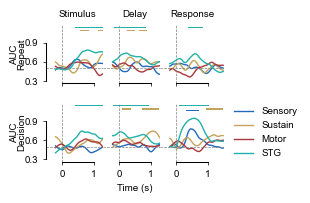

In [27]:
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter1d

LEX_TASK = "LexicalDelay"
LEX_DATATYPE = "lexicality"
LEX_ROIS = ["Sensory", "Sustain", "Motor", "STGl", "SMCl", "MFGl"]
LEX_PHASES = ["Stimulus", "Delay", "Response"]
LEX_DESCS = ["Repeat", "Decision"]
LEX_HUE = HUE_ORDER
CHANCE_AUC = 0.5
SMOOTH_SIGMA = 2
BAR_PAD = 0.01
BAR_HEIGHT = 0.02
YLIM_PAD = 0.1

lex_rows = []
missing = []
for roi in LEX_ROIS:
    display = roi[:-1] if roi.endswith("l") and roi not in FUNCTIONAL_ROIS else roi
    folder = (
        FUNCTIONAL_ROOT / LEX_TASK / f"sub-{roi}" / f"(decode)(resolved)(lda){LEX_DATATYPE}"
    )
    for phase in LEX_PHASES:
        for desc in LEX_DESCS:
            matches = sorted(
                folder.glob(f"sub-{roi}_proc-{phase}_*desc-{desc}_{BAND}.h5")
            )
            if not matches:
                missing.append(f"{roi}/{phase}/{desc}")
                continue
            with h5py.File(matches[0], "r") as mat:
                time = np.asarray(mat["time"][()], dtype=float)
                auc = np.asarray(mat["auc"][()], dtype=float)
                mask = np.asarray(mat["mask"][()]).astype(bool).ravel()
            lex_rows.append(
                pd.DataFrame(
                    {
                        "time": time,
                        "auc": gaussian_filter1d(auc, sigma=SMOOTH_SIGMA, mode="nearest"),
                        "auc_raw": auc,
                        "mask": mask,
                        "roi": display,
                        "phase": phase,
                        "description": desc,
                    }
                )
            )

if missing:
    print("missing", ", ".join(missing))
lex_scores = pd.concat(lex_rows, ignore_index=True)
print(
    lex_scores.groupby(["description", "phase", "roi"], sort=False)
    .agg(peak_auc=("auc_raw", "max"), n_sig=("mask", "sum"))
    .reset_index()
    .to_string(index=False)
)

palette = [ROI_COLOR_MAP[roi] for roi in LEX_HUE]
n_phases = len(LEX_PHASES)
n_descs = len(LEX_DESCS)
values = lex_scores["auc"].dropna()
ymin = max(0.0, float(values.min()) - YLIM_PAD)
ymax = float(values.max()) + YLIM_PAD
y_top = ymax + BAR_PAD + len(LEX_HUE) * (BAR_HEIGHT + 0.005) + 0.02

fig, axes = plt.subplots(
    n_descs,
    n_phases,
    figsize=(6.5 * cm, 4.5 * cm),
    sharex=True,
    sharey=False,
)
plt.subplots_adjust(wspace=-0.1, hspace=0.35, right=0.82)
auc_ticks = MaxNLocator(nbins=3).tick_values(ymin, ymax)
auc_ticks = auc_ticks[(auc_ticks >= ymin) & (auc_ticks <= ymax)]
for i, desc in enumerate(LEX_DESCS):
    scores = lex_scores[lex_scores["description"] == desc]
    for j, phase in enumerate(LEX_PHASES):
        ax = axes[i, j]
        subset = scores[scores["phase"] == phase]
        show_legend = i == n_descs - 1 and j == n_phases - 1
        sns.lineplot(
            data=subset,
            x="time",
            y="auc",
            hue="roi",
            palette=palette,
            hue_order=LEX_HUE,
            lw=1,
            ax=ax,
            legend=show_legend,
        )
        ax.set_autoscale_on(False)
        ax.margins(y=0)
        for k, roi in enumerate(LEX_HUE):
            roi_data = subset[subset["roi"] == roi].sort_values("time")
            if roi_data.empty or not roi_data["mask"].any():
                continue
            offset = k * (BAR_HEIGHT + 0.005)
            ax.fill_between(
                roi_data["time"].values,
                ymax + BAR_PAD + offset,
                ymax + BAR_PAD + BAR_HEIGHT + offset,
                where=roi_data["mask"].values,
                color=palette[k],
                alpha=1,
                step="mid",
                linewidth=0,
            )
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.axvline(x=0, color="gray", linestyle="--", lw=0.5)
        ax.axhline(y=CHANCE_AUC, color="gray", linestyle="--", lw=0.5)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(ymin, y_top)
        ax.set_xlabel("")
        ax.set_ylabel("AUC" if j == 0 else "", fontsize=fontsize)
        ax.set_title(phase if i == 0 else "", fontsize=fontsize)
        ax.set_yticks(auc_ticks)
        sns.despine(ax=ax, trim=True, offset=0.1)
        if j == 0:
            ax.yaxis.set_tick_params(labelleft=True)
        else:
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)
            ax.set_ylabel("")

    axes[i, 0].annotate(
        desc,
        xy=(-0.38, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center",
        fontsize=fontsize,
    )

axes[-1, n_phases // 2].set_xlabel("Time (s)", fontsize=fontsize)
if axes[-1, -1].get_legend() is not None:
    axes[-1, -1].legend(
        fontsize=fontsize,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )
out = save_svg(fig, IMG_DIR / "fig4_lexicality_LexicalDelay")
print("Wrote", out)


## Cross-condition lexicality (shrinkage-LDA)

2D train-time × test-time pooled OOF AUC from `(cross)(resolved)(lda)lexicality`.
Delay only. Train on Repeat, test on Decision. Chance is 0.5. Contours / filled
cells are 2D cluster-corrected `p < 0.05`. Reverse direction is on disk if
needed; this panel is the Aim 2.2 map.

Two views: the four-panel heatmap keeps the full AUC field. The overlay cell
stacks Sensory / Sustain / Motor on one axis — cluster-colored contours, AUC
filled only inside significant cells. STG is the same masked view as a control.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_cross_LexicalDelay_Repeat2Decision_Delay.svg
Sensory  peak=0.649  diag=0.536  n_sig=0
Sustain  peak=0.685  diag=0.562  n_sig=798
Motor    peak=0.630  diag=0.504  n_sig=0
STG      peak=0.812  diag=0.662  n_sig=2411


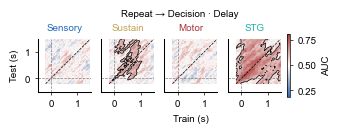

In [12]:
from matplotlib.colors import TwoSlopeNorm

CROSS_TASK = "LexicalDelay"
CROSS_DATATYPE = "lexicality"
CROSS_PHASE = "Delay"
CROSS_TRAIN = "Repeat"
CROSS_TEST = "Decision"
CROSS_ROIS = ["Sensory", "Sustain", "Motor", "STGl"]
CROSS_HUE = ["Sensory", "Sustain", "Motor", "STG"]
CHANCE_AUC = 0.5

cross_maps = {}
missing = []
for roi in CROSS_ROIS:
    display = roi[:-1] if roi.endswith("l") and roi not in FUNCTIONAL_ROIS else roi
    folder = (
        FUNCTIONAL_ROOT / CROSS_TASK / f"sub-{roi}" / f"(cross)(resolved)(lda){CROSS_DATATYPE}"
    )
    matches = sorted(
        folder.glob(
            f"sub-{roi}_proc-{CROSS_PHASE}_*desc-{CROSS_TRAIN}2{CROSS_TEST}_{BAND}.h5"
        )
    )
    if not matches:
        missing.append(f"{roi}/{CROSS_PHASE}/{CROSS_TRAIN}2{CROSS_TEST}")
        continue
    with h5py.File(matches[0], "r") as mat:
        cross_maps[display] = {
            "auc": np.asarray(mat["auc"][()], dtype=float),
            "mask": np.asarray(mat["mask"][()]).astype(bool),
            "train_time": np.asarray(mat["train_time"][()], dtype=float),
            "test_time": np.asarray(mat["test_time"][()], dtype=float),
        }

if missing:
    print("missing", ", ".join(missing))
if not cross_maps:
    print("No cross-condition H5s yet — run the STGl smoke, then the 8-job array.")
else:
    span = max(
        float(np.nanmax(np.abs(item["auc"] - CHANCE_AUC)))
        for item in cross_maps.values()
    )
    span = max(span, 0.05)
    n_roi = len(CROSS_HUE)
    fig, axes = plt.subplots(1, n_roi, figsize=(2.4 * n_roi * cm, 2.6 * cm), squeeze=False)
    last_im = None
    for j, roi in enumerate(CROSS_HUE):
        ax = axes[0, j]
        item = cross_maps.get(roi)
        if item is None:
            ax.set_axis_off()
            ax.set_title(roi, fontsize=fontsize)
            continue
        norm = TwoSlopeNorm(vmin=CHANCE_AUC - span, vcenter=CHANCE_AUC, vmax=CHANCE_AUC + span)
        last_im = ax.pcolormesh(
            item["train_time"],
            item["test_time"],
            item["auc"].T,
            cmap=sns.color_palette("vlag", as_cmap=True),
            norm=norm,
            shading="auto",
        )
        if item["mask"].any():
            ax.contour(
                item["train_time"],
                item["test_time"],
                item["mask"].T.astype(float),
                levels=[0.5],
                colors="black",
                linewidths=0.5,
            )
        ax.plot(
            [item["train_time"][0], item["train_time"][-1]],
            [item["test_time"][0], item["test_time"][-1]],
            color="black",
            linestyle="--",
            linewidth=0.5,
        )
        ax.axvline(0, color="gray", linestyle="--", lw=0.5)
        ax.axhline(0, color="gray", linestyle="--", lw=0.5)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.set_title(roi, fontsize=fontsize, color=ROI_COLOR_MAP[roi])
        if j != 0:
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)
        sns.despine(ax=ax, offset=0.1)
    fig.suptitle(
        f"Lexicality · {CROSS_PHASE}",
        fontsize=fontsize,
        y=1.06,
    )
    fig.supxlabel(
        f"Train on {CROSS_TRAIN} (s)",
        fontsize=fontsize,
        y=-0.06,
    )
    fig.supylabel(
        f"Test on {CROSS_TEST} (s)",
        fontsize=fontsize,
        x=-0.01,
    )
    fig.text(
        1.0,
        -0.08,
        "p < 0.05",
        ha="right",
        va="top",
        fontsize=fontsize,
    )
    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02)
        cbar.set_label("AUC", fontsize=fontsize)
        cbar.ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        cbar.outline.set_linewidth(0.5)
    out = save_svg(
        fig,
        IMG_DIR / f"fig4_cross_{CROSS_TASK}_{CROSS_TRAIN}2{CROSS_TEST}_{CROSS_PHASE}",
    )
    print("Wrote", out)
    for roi, item in cross_maps.items():
        print(
            f"{roi:8s} peak={item['auc'].max():.3f}  "
            f"diag={np.nanmean(np.diag(item['auc'])):.3f}  "
            f"n_sig={int(item['mask'].sum())}"
        )


Overlay: Sensory / Sustain / Motor on one axis. Only significant cells are
filled (`p < 0.05`, cluster-corrected); here that is Sustain. STG is the same
masked view, not stacked with the insula clusters. A third panel overlays
Sustain and STG. Peak AUC is annotated at the significant-cell argmax.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_cross_LexicalDelay_Repeat2Decision_Delay_overlay.svg
Sensory  sig_peak=nan  n_sig=0
Sustain  sig_peak=0.685  n_sig=798
Motor    sig_peak=nan  n_sig=0
STG      sig_peak=0.812  n_sig=2411


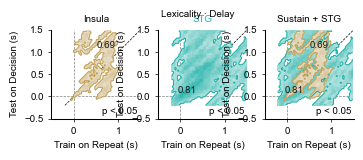

In [20]:
OVERLAY_ROIS = ["Sensory", "Sustain", "Motor"]
OVERLAY_STG = "STG"
CHANCE_AUC = 0.5
CROSS_TASK = "LexicalDelay"
CROSS_DATATYPE = "lexicality"
CROSS_PHASE = "Delay"
CROSS_TRAIN = "Repeat"
CROSS_TEST = "Decision"

overlay_maps = {}
for roi in ["Sensory", "Sustain", "Motor", "STGl"]:
    display = roi[:-1] if roi.endswith("l") and roi not in FUNCTIONAL_ROIS else roi
    folder = (
        FUNCTIONAL_ROOT / CROSS_TASK / f"sub-{roi}" / f"(cross)(resolved)(lda){CROSS_DATATYPE}"
    )
    matches = sorted(
        folder.glob(
            f"sub-{roi}_proc-{CROSS_PHASE}_*desc-{CROSS_TRAIN}2{CROSS_TEST}_{BAND}.h5"
        )
    )
    if not matches:
        continue
    with h5py.File(matches[0], "r") as mat:
        overlay_maps[display] = {
            "auc": np.asarray(mat["auc"][()], dtype=float),
            "mask": np.asarray(mat["mask"][()]).astype(bool),
            "train_time": np.asarray(mat["train_time"][()], dtype=float),
            "test_time": np.asarray(mat["test_time"][()], dtype=float),
        }

if not overlay_maps:
    raise RuntimeError("No cross-condition H5s found for the overlay panel.")

sig_devs = []
for roi in (*OVERLAY_ROIS, OVERLAY_STG):
    item = overlay_maps.get(roi)
    if item is None or not item["mask"].any():
        continue
    sig_devs.append(float(np.nanmax(item["auc"][item["mask"]]) - CHANCE_AUC))
span = max(sig_devs) if sig_devs else 0.05
span = max(span, 0.05)
vmax = CHANCE_AUC + span

fig, axes = plt.subplots(1, 3, figsize=(3.3 * 3 * cm, 3 * cm), squeeze=False)
ax_ov, ax_stg, ax_both = axes[0]


def _style_tg_ax(ax, item):
    t0, t1 = float(item["train_time"][0]), float(item["train_time"][-1])
    s0, s1 = float(item["test_time"][0]), float(item["test_time"][-1])
    ax.plot([t0, t1], [s0, s1], color="black", linestyle="--", linewidth=0.5, zorder=0)
    ax.axvline(0, color="gray", linestyle="--", lw=0.5, zorder=0)
    ax.axhline(0, color="gray", linestyle="--", lw=0.5, zorder=0)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=fontsize, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=0.1)
    ax.text(
        0.97,
        0.03,
        "p < 0.05",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=fontsize,
        zorder=4,
    )


def _masked_field(ax, item, contour_color, annotate=True):
    if item is None:
        ax.set_axis_off()
        return
    if item["mask"].any():
        shown = np.ma.masked_where(~item["mask"], item["auc"])
        cmap = sns.light_palette(contour_color, as_cmap=True)
        ax.pcolormesh(
            item["train_time"],
            item["test_time"],
            shown.T,
            cmap=cmap,
            vmin=CHANCE_AUC,
            vmax=vmax,
            shading="auto",
            zorder=1,
        )
        ax.contour(
            item["train_time"],
            item["test_time"],
            item["mask"].T.astype(float),
            levels=[0.5],
            colors=[contour_color],
            linewidths=0.8,
            zorder=2,
        )
        if annotate:
            peak = float(np.nanmax(item["auc"][item["mask"]]))
            peak_idx = np.nanargmax(np.where(item["mask"], item["auc"], -np.inf))
            i_train, i_test = np.unravel_index(peak_idx, item["auc"].shape)
            ax.text(
                item["train_time"][i_train],
                item["test_time"][i_test],
                f"{peak:.2f}",
                fontsize=fontsize,
                ha="center",
                va="center",
                color="0.1",
                zorder=3,
            )


for roi in ("Sensory", "Motor", "Sustain"):
    item = overlay_maps.get(roi)
    if item is None:
        continue
    _masked_field(ax_ov, item, ROI_COLOR_MAP[roi], annotate=item["mask"].any())

_style_item = next((overlay_maps[r] for r in OVERLAY_ROIS if r in overlay_maps), None)
if _style_item is not None:
    _style_tg_ax(ax_ov, _style_item)
else:
    ax_ov.set_axis_off()

ax_ov.set_title("Insula", fontsize=fontsize)
ax_ov.set_xlabel(f"Train on {CROSS_TRAIN} (s)", fontsize=fontsize)
ax_ov.set_ylabel(f"Test on {CROSS_TEST} (s)", fontsize=fontsize)

_masked_field(
    ax_stg,
    overlay_maps.get(OVERLAY_STG),
    ROI_COLOR_MAP[OVERLAY_STG],
    annotate=True,
)
if overlay_maps.get(OVERLAY_STG) is not None:
    _style_tg_ax(ax_stg, overlay_maps[OVERLAY_STG])
ax_stg.set_title("STG", fontsize=fontsize, color=ROI_COLOR_MAP[OVERLAY_STG])
ax_stg.set_xlabel(f"Train on {CROSS_TRAIN} (s)", fontsize=fontsize)
ax_stg.set_ylabel(f"Test on {CROSS_TEST} (s)", fontsize=fontsize)

_masked_field(
    ax_both,
    overlay_maps.get(OVERLAY_STG),
    ROI_COLOR_MAP[OVERLAY_STG],
    annotate=True,
)
_masked_field(
    ax_both,
    overlay_maps.get("Sustain"),
    ROI_COLOR_MAP["Sustain"],
    annotate=True,
)
_both_item = overlay_maps.get(OVERLAY_STG) or overlay_maps.get("Sustain")
if _both_item is not None:
    _style_tg_ax(ax_both, _both_item)
ax_both.set_title("Sustain + STG", fontsize=fontsize)
ax_both.set_xlabel(f"Train on {CROSS_TRAIN} (s)", fontsize=fontsize)
ax_both.set_ylabel(f"Test on {CROSS_TEST} (s)", fontsize=fontsize)

fig.suptitle(
    f"Lexicality · {CROSS_PHASE}",
    fontsize=fontsize,
    y=1.04,
)
out = save_svg(
    fig,
    IMG_DIR / f"fig4_cross_{CROSS_TASK}_{CROSS_TRAIN}2{CROSS_TEST}_{CROSS_PHASE}_overlay",
)
print("Wrote", out)
for roi in (*OVERLAY_ROIS, OVERLAY_STG):
    item = overlay_maps.get(roi)
    if item is None:
        print(f"{roi:8s} missing")
        continue
    n_sig = int(item["mask"].sum())
    if n_sig:
        peak = float(np.nanmax(item["auc"][item["mask"]]))
    else:
        peak = float("nan")
    print(f"{roi:8s} sig_peak={peak:.3f}  n_sig={n_sig}")


## Supplement: anatomical cross-condition (STG / SMC / MFG / IFG)

Same Delay shrinkage-LDA maps as the main four-panel row, left hemisphere only. Production files are `n_perm=5000`. First figure is Repeat→Decision (the Aim 2.2 direction); second is Decision→Repeat. IFG is Hammers `IFG` only. Color axis centered at chance 0.5. Do not change the main Sensory / Sustain / Motor / STG panel.

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_cross_LexicalDelay_Repeat2Decision_Delay_anat.svg
Repeat2Decision  STG      n_ch=92  n_perm=5000  peak=0.812  diag=0.662  n_sig=2411
Repeat2Decision  SMC      n_ch=32  n_perm=5000  peak=0.654  diag=0.546  n_sig=347
Repeat2Decision  MFG      n_ch=68  n_perm=5000  peak=0.712  diag=0.571  n_sig=547
Repeat2Decision  IFG      n_ch=70  n_perm=5000  peak=0.708  diag=0.594  n_sig=944
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig4/fig4_cross_LexicalDelay_Decision2Repeat_Delay_anat.svg
Decision2Repeat  STG      n_ch=92  n_perm=5000  peak=0.798  diag=0.654  n_sig=2059
Decision2Repeat  SMC      n_ch=32  n_perm=5000  peak=0.669  diag=0.533  n_sig=218
Decision2Repeat  MFG      n_ch=68  n_perm=5000  peak=0.709  diag=0.573  n_sig=465
Decision2Repeat  IFG      n_ch=70  n_perm=5000  peak=0.682  diag=0.576  n_sig=861


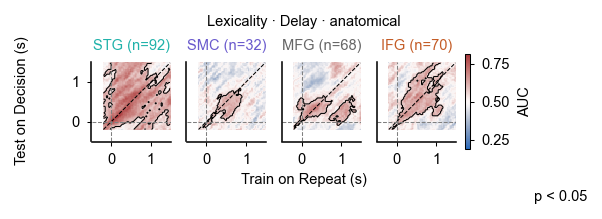

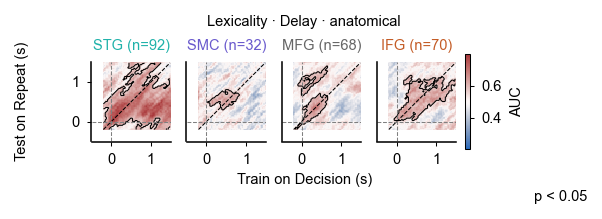

In [22]:
from matplotlib.colors import TwoSlopeNorm

SUPP_CROSS_TASK = "LexicalDelay"
SUPP_CROSS_DATATYPE = "lexicality"
SUPP_CROSS_PHASE = "Delay"
SUPP_CROSS_ROIS = ["STGl", "SMCl", "MFGl", "IFGl"]
SUPP_CROSS_HUE = ["STG", "SMC", "MFG", "IFG"]
SUPP_CROSS_DIRS = (("Repeat", "Decision"), ("Decision", "Repeat"))
CHANCE_AUC = 0.5


def _load_supp_cross(train, test):
    maps = {}
    nch = {}
    missing = []
    for roi in SUPP_CROSS_ROIS:
        display = roi[:-1] if roi.endswith("l") and roi not in FUNCTIONAL_ROIS else roi
        folder = (
            FUNCTIONAL_ROOT
            / SUPP_CROSS_TASK
            / f"sub-{roi}"
            / f"(cross)(resolved)(lda){SUPP_CROSS_DATATYPE}"
        )
        matches = sorted(
            folder.glob(
                f"sub-{roi}_proc-{SUPP_CROSS_PHASE}_*desc-{train}2{test}_{BAND}.h5"
            )
        )
        if not matches:
            missing.append(f"{roi}/{SUPP_CROSS_PHASE}/{train}2{test}")
            continue
        with h5py.File(matches[0], "r") as mat:
            maps[display] = {
                "auc": np.asarray(mat["auc"][()], dtype=float),
                "mask": np.asarray(mat["mask"][()]).astype(bool),
                "train_time": np.asarray(mat["train_time"][()], dtype=float),
                "test_time": np.asarray(mat["test_time"][()], dtype=float),
            }
            if "channel" in mat:
                nch[display] = int(np.asarray(mat["channel"][()]).shape[0])
            n_perm = int(mat.attrs.get("n_perm", -1))
        maps[display]["n_perm"] = n_perm
    return maps, nch, missing


for SUPP_CROSS_TRAIN, SUPP_CROSS_TEST in SUPP_CROSS_DIRS:
    supp_maps, supp_nch, supp_missing = _load_supp_cross(
        SUPP_CROSS_TRAIN, SUPP_CROSS_TEST
    )
    if supp_missing:
        print("missing", ", ".join(supp_missing))
    if set(SUPP_CROSS_HUE) - set(supp_maps):
        print(
            f"skip {SUPP_CROSS_TRAIN}2{SUPP_CROSS_TEST}: "
            + ", ".join(sorted(set(SUPP_CROSS_HUE) - set(supp_maps)))
        )
        continue
    span = max(
        float(np.nanmax(np.abs(item["auc"] - CHANCE_AUC)))
        for item in supp_maps.values()
    )
    span = max(span, 0.05)
    n_roi = len(SUPP_CROSS_HUE)
    fig, axes = plt.subplots(1, n_roi, figsize=(2.4 * n_roi * cm, 2.6 * cm), squeeze=False)
    last_im = None
    for j, roi in enumerate(SUPP_CROSS_HUE):
        ax = axes[0, j]
        item = supp_maps[roi]
        nch = supp_nch.get(roi)
        title = f"{roi} (n={nch})" if nch is not None else roi
        norm = TwoSlopeNorm(
            vmin=CHANCE_AUC - span, vcenter=CHANCE_AUC, vmax=CHANCE_AUC + span
        )
        last_im = ax.pcolormesh(
            item["train_time"],
            item["test_time"],
            item["auc"].T,
            cmap=sns.color_palette("vlag", as_cmap=True),
            norm=norm,
            shading="auto",
        )
        if item["mask"].any():
            ax.contour(
                item["train_time"],
                item["test_time"],
                item["mask"].T.astype(float),
                levels=[0.5],
                colors="black",
                linewidths=0.5,
            )
        ax.plot(
            [item["train_time"][0], item["train_time"][-1]],
            [item["test_time"][0], item["test_time"][-1]],
            color="black",
            linestyle="--",
            linewidth=0.5,
        )
        ax.axvline(0, color="gray", linestyle="--", lw=0.5)
        ax.axhline(0, color="gray", linestyle="--", lw=0.5)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.set_title(title, fontsize=fontsize, color=ROI_COLOR_MAP[roi])
        if j != 0:
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)
        sns.despine(ax=ax, offset=0.1)
    fig.suptitle(
        f"Lexicality · {SUPP_CROSS_PHASE} · anatomical",
        fontsize=fontsize,
        y=1.06,
    )
    fig.supxlabel(
        f"Train on {SUPP_CROSS_TRAIN} (s)",
        fontsize=fontsize,
        y=-0.06,
    )
    fig.supylabel(
        f"Test on {SUPP_CROSS_TEST} (s)",
        fontsize=fontsize,
        x=-0.01,
    )
    fig.text(
        1.0,
        -0.08,
        "p < 0.05",
        ha="right",
        va="top",
        fontsize=fontsize,
    )
    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02)
        cbar.set_label("AUC", fontsize=fontsize)
        cbar.ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        cbar.outline.set_linewidth(0.5)
    out = save_svg(
        fig,
        IMG_DIR
        / f"fig4_cross_{SUPP_CROSS_TASK}_{SUPP_CROSS_TRAIN}2{SUPP_CROSS_TEST}_{SUPP_CROSS_PHASE}_anat",
    )
    display(fig)
    plt.close(fig)
    print("Wrote", out)
    for roi in SUPP_CROSS_HUE:
        item = supp_maps[roi]
        nch = supp_nch.get(roi, "?")
        print(
            f"{SUPP_CROSS_TRAIN}2{SUPP_CROSS_TEST}  {roi:8s} n_ch={nch}  "
            f"n_perm={item['n_perm']}  peak={item['auc'].max():.3f}  "
            f"diag={np.nanmean(np.diag(item['auc'])):.3f}  "
            f"n_sig={int(item['mask'].sum())}"
        )

